In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path
import numpy as np

from myViT import VisionTransformer
from ViTTrainer import ViT_train
from view_preds import show_prediction_side_by_side
from sched_optim import build_optimizer_and_scheduler
from plot_losses import plot_losses
from build_dataloaders_ViT import build_train_dl
from sanity_test_overfit import run_sanity_suite
import build_dataloaders_ViT

import sys
repo_root = Path.cwd()
if not (repo_root / "v2").is_dir():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from v2.CarImageClass import ImageClass, make_train_test_split
from v2.training_files.save_load_ckpt import load_checkpoint
from v2.training_files.CondIoUCrop import ConditionalIoUCrop


device = "cuda" if torch.cuda.is_available() else "cpu"

# set file path
# desktop or laptop
machine = 'desktop'

# Setup path to data folder
if machine == 'laptop':
    folder_path = Path(r"C:\self-driving-car\data")
else:
    folder_path = Path(r"C:\Udacity_car_data\data")

train_path = folder_path / "train"
test_path = folder_path / "test"


def collate_detection(batch):
    # batch: list of (img, target) tuples
    imgs  = [img for img, _ in batch]
    tgts  = [tgt for _, tgt in batch]
    return torch.stack(imgs, dim=0), tgts

In [4]:
# grad clip 1.0

sanity_runs = run_sanity_suite(
    train_path=train_path,
    num_images=9,
    file_pct=0.0005,
    one_image_steps=2_000,
    all_image_steps=10_000,
    eval_every=100,
    learning_rate=3e-4,
    seed=724,
    device=device,
    grad_clip_val=1.0,
)

for name, result in sanity_runs.items():
    best = max(result.history, key=lambda row: row["map50"])
    final = result.history[-1]

    print(f"\n{name}")
    print("best:", best)
    print("final:", final)

Frozen 9 images; object counts: [8, 2, 5, 12, 6, 0, 11, 7, 9]

ONE-IMAGE SANITY TEST: 1 image(s), one optimizer step per iteration, lr=0.0003, grad_clip_val=1
step=    1  loss=10.3018  CE=3.6499  L1=0.5344  GIoU=1.9899  mAP@.50=0.0000  pre-clip |g|=39.8140  post-clip |g|=1.0000
step=  100  loss=5.5490  CE=1.1883  L1=0.1136  GIoU=1.8963  mAP@.50=0.0000  pre-clip |g|=176.5038  post-clip |g|=1.0000
step=  200  loss=4.8488  CE=0.7467  L1=0.0920  GIoU=1.8210  mAP@.50=0.0000  pre-clip |g|=328.2294  post-clip |g|=1.0000
step=  300  loss=4.3542  CE=0.4286  L1=0.0861  GIoU=1.7475  mAP@.50=0.0000  pre-clip |g|=141.9705  post-clip |g|=1.0000
step=  400  loss=4.1036  CE=0.2697  L1=0.0987  GIoU=1.6702  mAP@.50=0.0000  pre-clip |g|=144.0566  post-clip |g|=1.0000
step=  500  loss=4.0551  CE=0.1989  L1=0.0871  GIoU=1.7103  mAP@.50=0.0000  pre-clip |g|=154.3117  post-clip |g|=1.0000
step=  600  loss=3.8658  CE=0.1491  L1=0.0890  GIoU=1.6358  mAP@.50=0.0000  pre-clip |g|=151.7457  post-clip |g|=1.0000
s

In [5]:
# grad clip 10.0

sanity_runs = run_sanity_suite(
    train_path=train_path,
    num_images=9,
    file_pct=0.0005,
    one_image_steps=2_000,
    all_image_steps=10_000,
    eval_every=100,
    learning_rate=3e-4,
    seed=724,
    device=device,
    grad_clip_val=10.0,
)

for name, result in sanity_runs.items():
    best = max(result.history, key=lambda row: row["map50"])
    final = result.history[-1]

    print(f"\n{name}")
    print("best:", best)
    print("final:", final)

Frozen 9 images; object counts: [8, 2, 5, 12, 6, 0, 11, 7, 9]

ONE-IMAGE SANITY TEST: 1 image(s), one optimizer step per iteration, lr=0.0003, grad_clip_val=10
step=    1  loss=10.3018  CE=3.6499  L1=0.5344  GIoU=1.9899  mAP@.50=0.0000  pre-clip |g|=39.8140  post-clip |g|=10.0000
step=  100  loss=5.2443  CE=1.3404  L1=0.1048  GIoU=1.6899  mAP@.50=0.0000  pre-clip |g|=130.4212  post-clip |g|=10.0000
step=  200  loss=4.8390  CE=0.8575  L1=0.1018  GIoU=1.7362  mAP@.50=0.0000  pre-clip |g|=727.2843  post-clip |g|=10.0000
step=  300  loss=4.3091  CE=0.4323  L1=0.0968  GIoU=1.6964  mAP@.50=0.0000  pre-clip |g|=449.7638  post-clip |g|=10.0000
step=  400  loss=4.0063  CE=0.1735  L1=0.0914  GIoU=1.6879  mAP@.50=0.0000  pre-clip |g|=174.5227  post-clip |g|=10.0000
step=  500  loss=3.9076  CE=0.1184  L1=0.0942  GIoU=1.6590  mAP@.50=0.0000  pre-clip |g|=65.7884  post-clip |g|=10.0000
step=  600  loss=3.8888  CE=0.0798  L1=0.0944  GIoU=1.6684  mAP@.50=0.0000  pre-clip |g|=139.0366  post-clip |g|=10

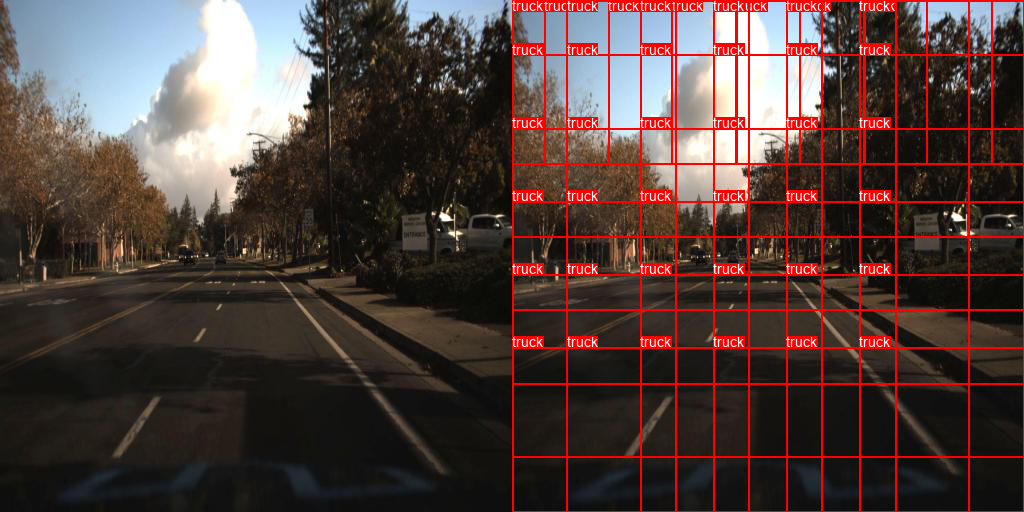

In [ ]:
ViTmodel_no_train = VisionTransformer(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                             img_size=300,
                             patch_H=15,
                             patch_W=10,
                             in_channels=3,
                             embed_dim=256,
                             num_layers=6,
                             num_heads=4,
                             dim_feedforward=256*4,
                             dropout=0.1,
                             num_queries=50).to(device)

train_data = ImageClass(targ_dir=train_path, transform=None, file_pct=1, rand_seed=724, include_area=False)

show_prediction_side_by_side(model=ViTmodel_no_train,
                             image_path=train_data.paths[5],
                             #image_path=r"C:\Udacity_car_data\data\test\1478020225692825294_jpg.rf.56eb69377e7d753621a360ec59206e2f.jpg",
                             pil_img=None,
                             conf_thresh=0.0)

In [5]:
ViTmodel = VisionTransformer(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                             img_size=300,
                             patch_H=15,
                             patch_W=10,
                             in_channels=3,
                             embed_dim=256,
                             num_layers=6,
                             num_heads=4,
                             dim_feedforward=256*4,
                             dropout=0.0,
                             num_queries=50).to(device)

total_params = sum(p.numel() for p in ViTmodel.parameters())

print(f"Total parameters: {total_params:,}")

Total parameters: 11,322,634


In [2]:
# ~11.3 million parameters
ViTmodel = VisionTransformer(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                             img_size=300,
                             patch_H=15,
                             patch_W=10,
                             in_channels=3,
                             embed_dim=256,
                             num_layers=6,
                             num_heads=4,
                             dim_feedforward=256*4,
                             dropout=0.1,
                             num_queries=50).to(device)

resume_path = repo_root / "myTransformer" / "saved_models" / "epoch290_mAP_on_val_7230.ckpt"
if resume_path.exists():
    start_epoch, best_map, loss_dict = load_checkpoint(
        resume_path, ViTmodel, optimizer=None, scheduler=None,
        scaler=None, map_location="cpu"  # safe load, then move to device
    )
    ViTmodel.to(device)

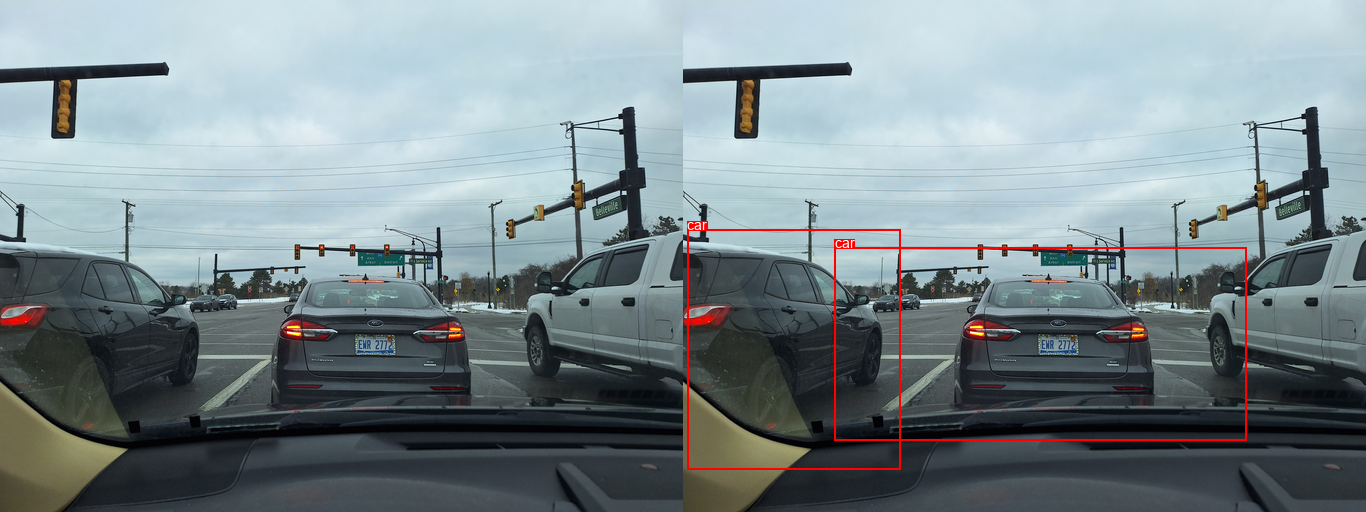

In [3]:
show_prediction_side_by_side(model=ViTmodel,
                             #image_path=test_data.paths[700],
                             image_path=r"D:\Desktop\test files\20251202_132143.jpg",
                             pil_img=None,
                             conf_thresh=0.95)

In [4]:
tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
    ])
train_data = ImageClass(targ_dir=train_path, transform=tfms, file_pct=1, rand_seed=724, include_area=False)
test_data = ImageClass(targ_dir=test_path, transform=tfms, file_pct=1, rand_seed=724, include_area=False)

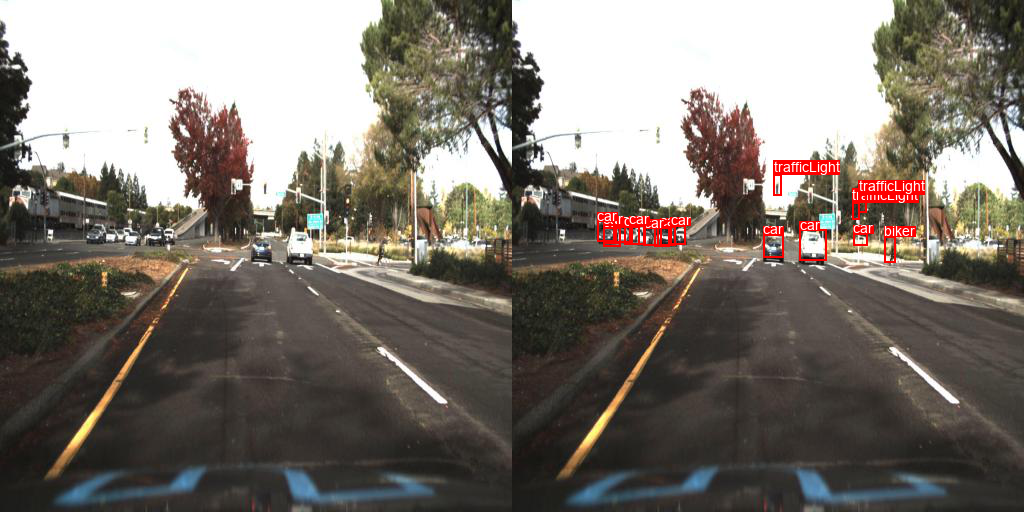

In [5]:
show_prediction_side_by_side(model=ViTmodel,
                             image_path=test_data.paths[700],
                             #image_path=r"C:\Udacity_car_data\data\test\1478020225692825294_jpg.rf.56eb69377e7d753621a360ec59206e2f.jpg",
                             pil_img=None,
                             conf_thresh=0.95)

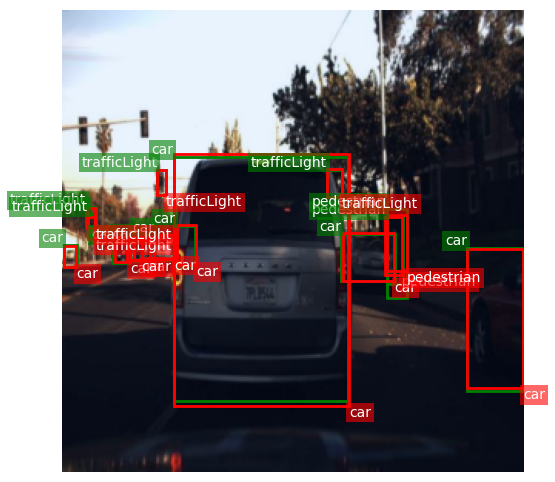

In [6]:
idx = 2000

preds = ViTmodel.predict(test_data[idx][0].unsqueeze(0).to(device='cuda'), conf_thresh=0.95)[0]

test_data.show_with_box(index=idx,
                        label=True,
                        pred_dict=preds,
                        pred_label=True);

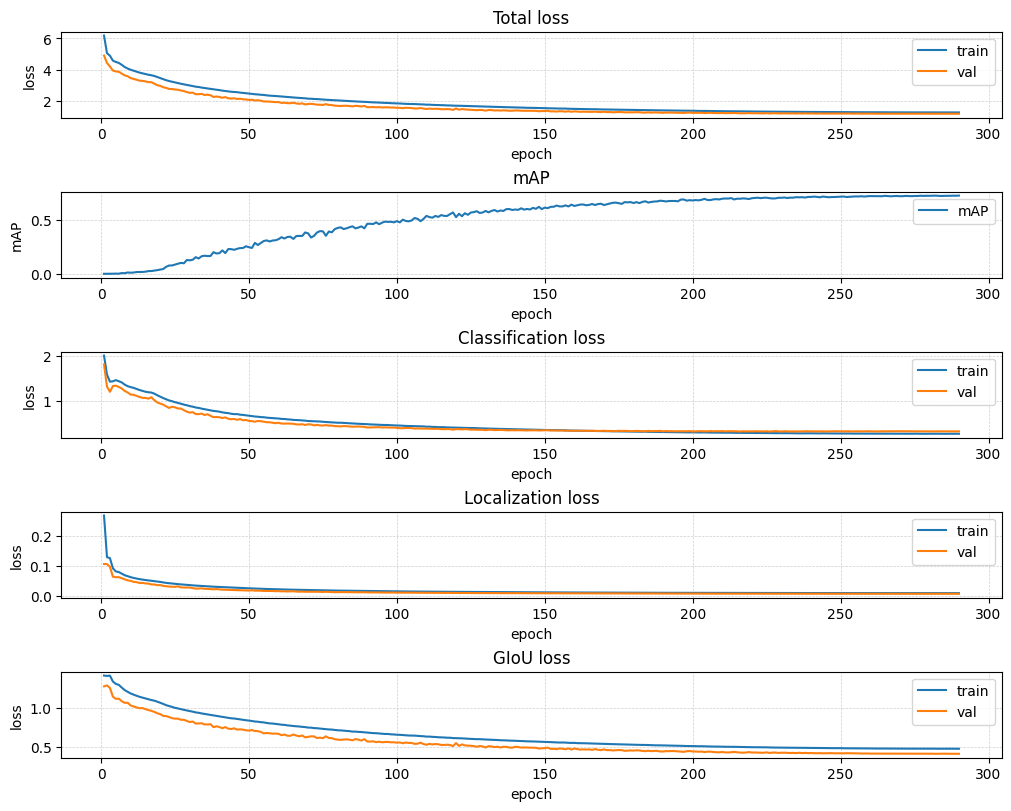

In [3]:
plot_losses(loss_dict)

In [4]:
test_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

test_data = ImageClass(targ_dir=test_path, transform=test_tfms, file_pct=1, rand_seed=724, include_area=False)

import build_dataloaders_ViT

test_dataloader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=2,
    pin_memory=False,
    collate_fn=build_dataloaders_ViT.collate_detection,
    multiprocessing_context="spawn",
)

map_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', iou_thresholds=[0.50], class_metrics=True).to(device)
map_metric.reset()

for images, targets in test_dataloader:
    # no confidence threshold
    preds = ViTmodel.predict(images.to(device))   # list[dict] per image
    # ensure preds/targets tensors are on `device` and labels are 0..C-1
    for i in range(len(targets)):
        for key in targets[i].keys():
            targets[i][key] = targets[i][key].to(device)
    
    map_metric.update(preds=preds, target=targets)

mAP_test_results = map_metric.compute()

mAP_test_results

{'map': tensor(0.7310),
 'map_50': tensor(0.7310),
 'map_75': tensor(-1.),
 'map_small': tensor(0.7040),
 'map_medium': tensor(0.8872),
 'map_large': tensor(0.9601),
 'mar_1': tensor(0.3525),
 'mar_10': tensor(0.8217),
 'mar_100': tensor(0.8476),
 'mar_small': tensor(0.8285),
 'mar_medium': tensor(0.9572),
 'mar_large': tensor(0.9938),
 'map_per_class': tensor([0.6407, 0.8602, 0.5129, 0.7696, 0.8717]),
 'mar_100_per_class': tensor([0.8028, 0.9310, 0.7394, 0.8423, 0.9225]),
 'classes': tensor([0, 1, 2, 3, 4], dtype=torch.int32)}

In [5]:
test_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

test_data = ImageClass(targ_dir=test_path, transform=test_tfms, file_pct=1, rand_seed=724, include_area=False)

test_dataloader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=2,
    pin_memory=False,
    collate_fn=build_dataloaders_ViT.collate_detection,
    multiprocessing_context="spawn",
)

map_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', iou_thresholds=[0.50], class_metrics=True).to(device)
map_metric.reset()

for images, targets in test_dataloader:
    preds = ViTmodel.predict(images.to(device), conf_thresh=0.95)   # list[dict] per image
    for i in range(len(targets)):
        for key in targets[i].keys():
            targets[i][key] = targets[i][key].to(device)
    
    map_metric.update(preds=preds, target=targets)

mAP_test_results = map_metric.compute()

mAP_test_results

{'map': tensor(0.6463),
 'map_50': tensor(0.6463),
 'map_75': tensor(-1.),
 'map_small': tensor(0.6228),
 'map_medium': tensor(0.7920),
 'map_large': tensor(0.7925),
 'mar_1': tensor(0.3283),
 'mar_10': tensor(0.7014),
 'mar_100': tensor(0.7093),
 'mar_small': tensor(0.6910),
 'mar_medium': tensor(0.8274),
 'mar_large': tensor(0.8101),
 'map_per_class': tensor([0.5363, 0.7653, 0.4165, 0.7224, 0.7910]),
 'mar_100_per_class': tensor([0.6139, 0.7986, 0.5436, 0.7757, 0.8148]),
 'classes': tensor([0, 1, 2, 3, 4], dtype=torch.int32)}